c:\Users\максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


base: покрытие 0.0%
dc: покрытие 0.0%
top_dc: покрытие 0.0%
Графики сохранены в data/result/notebook_output/


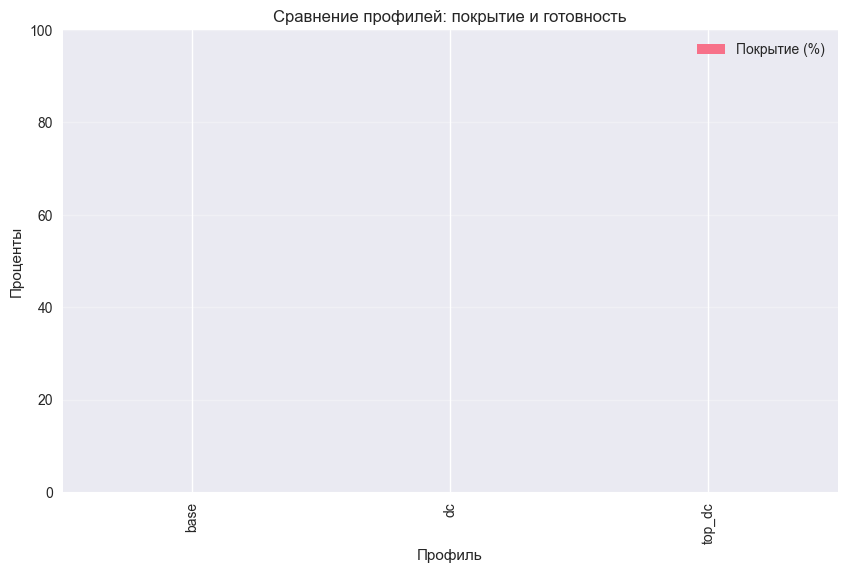

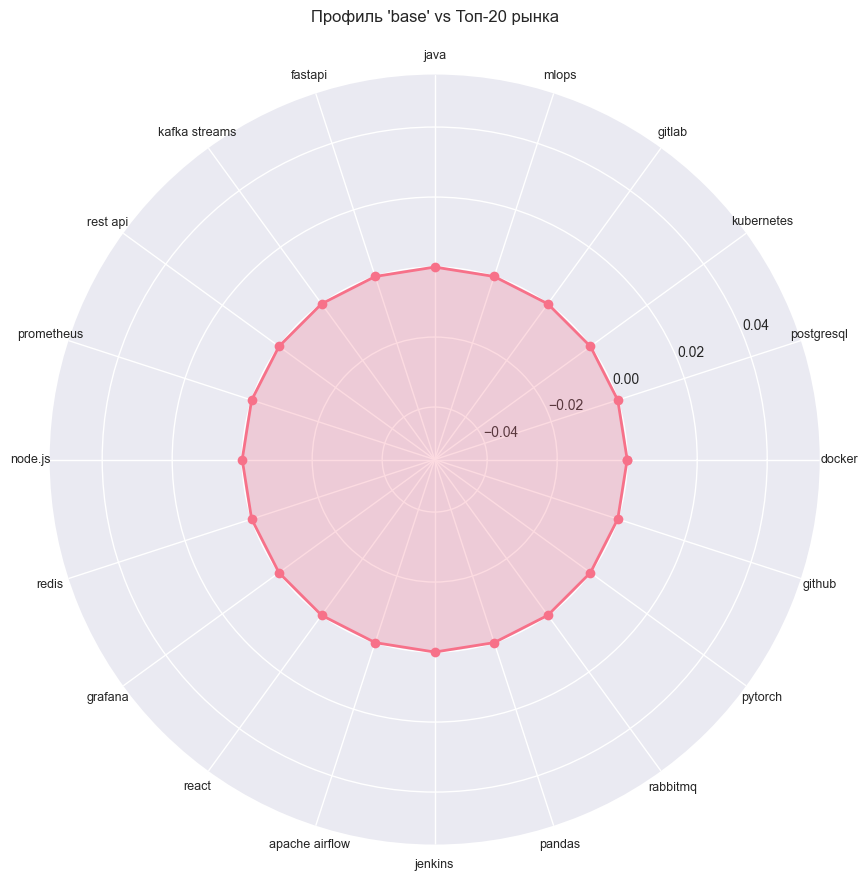

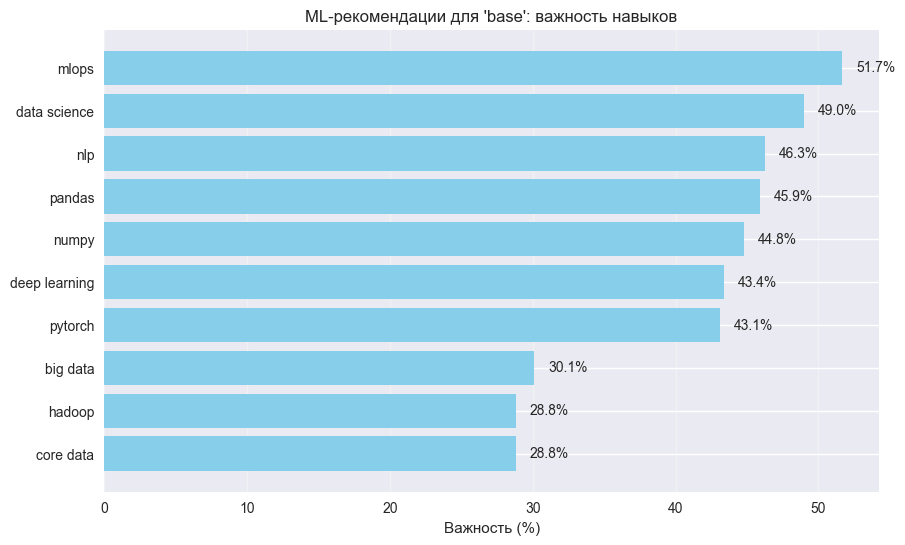

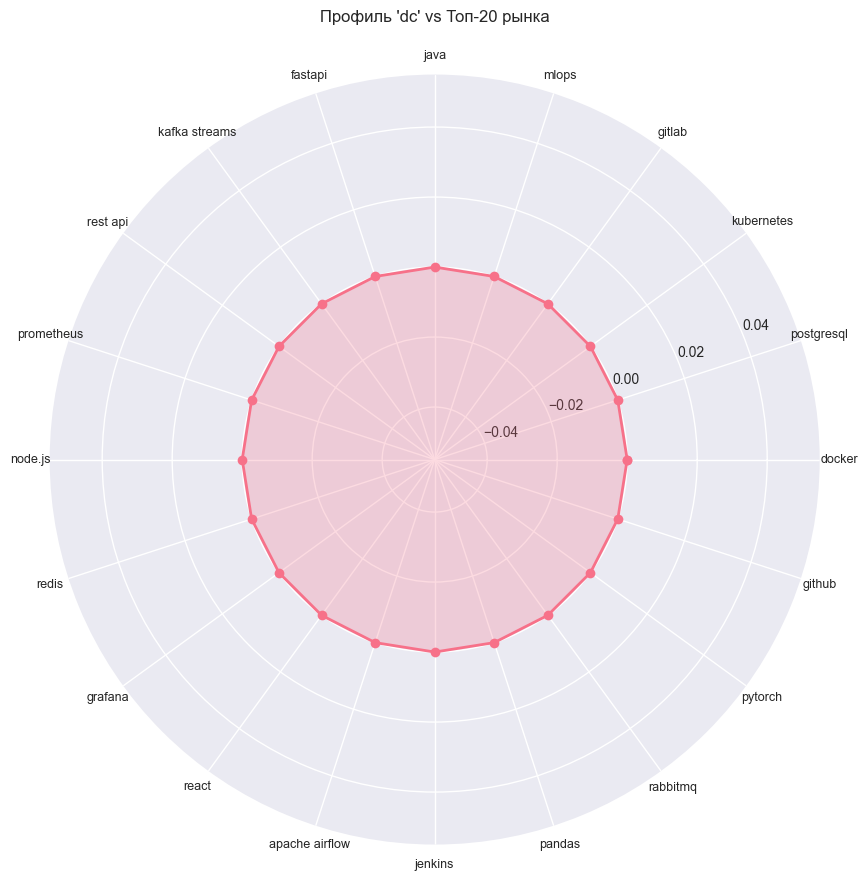

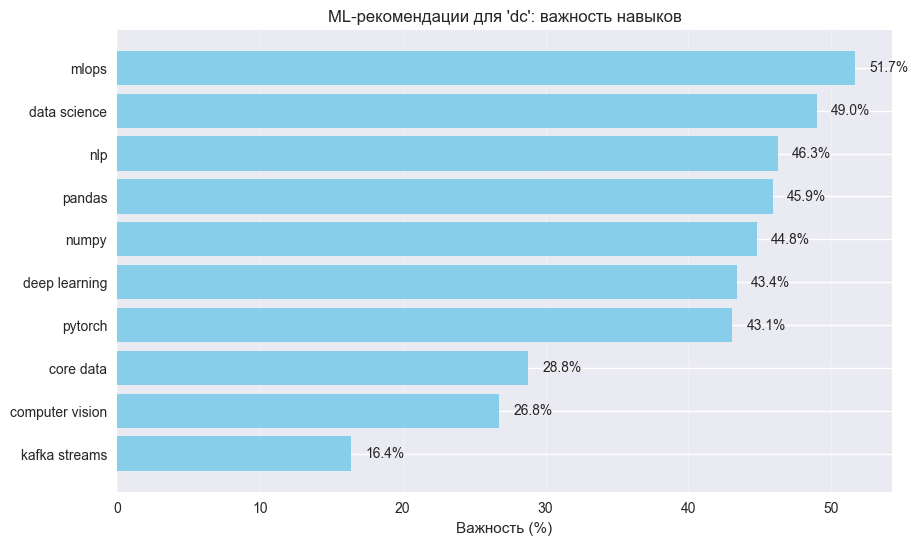

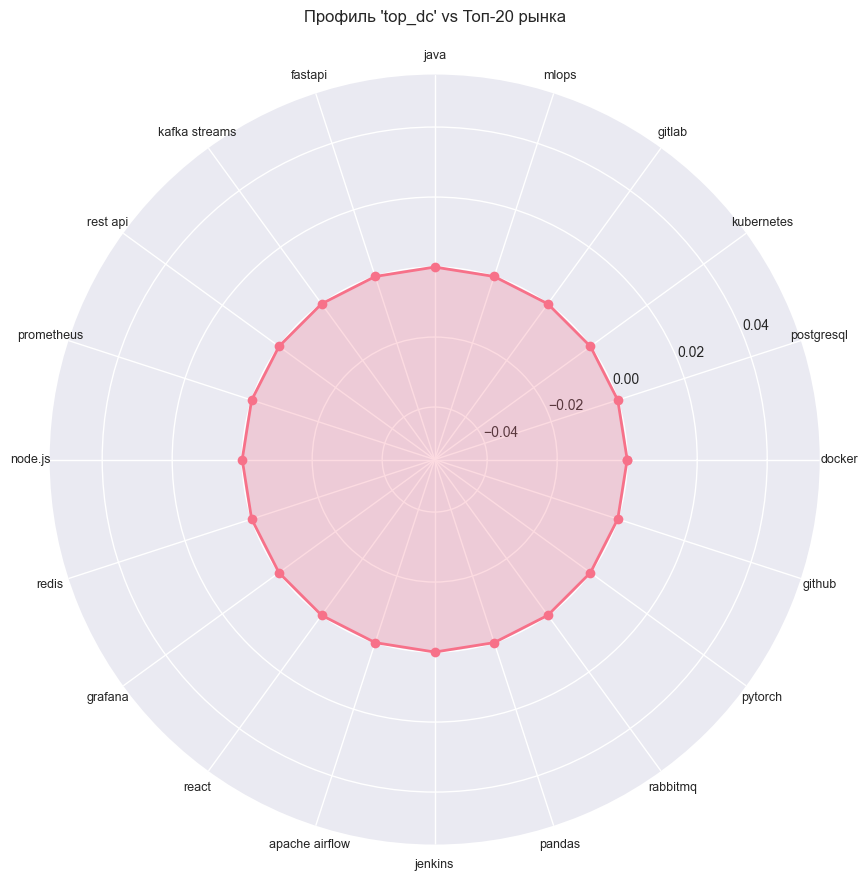

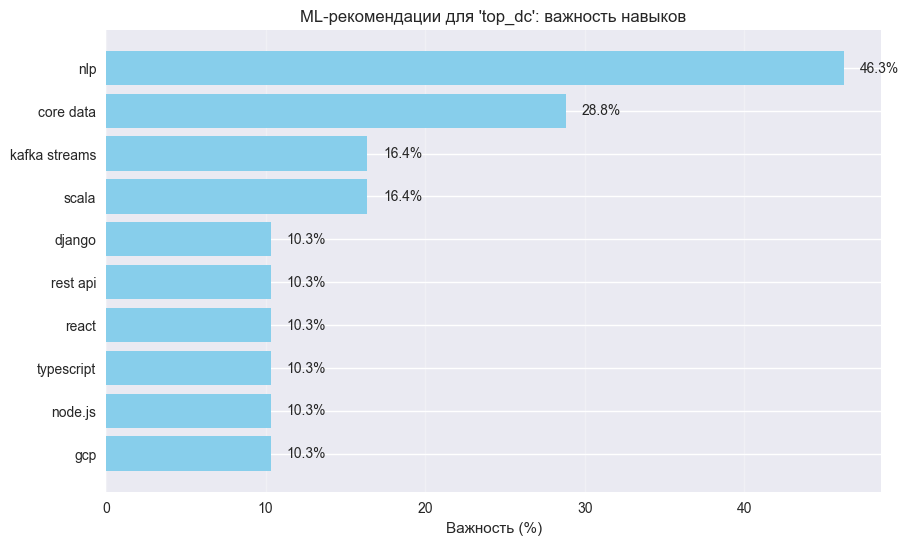

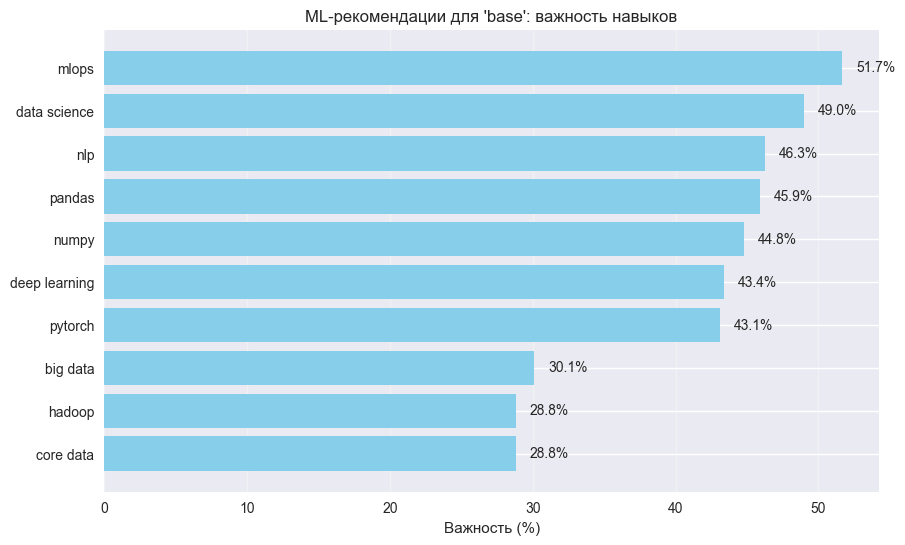

In [1]:
# %% [markdown]
# # Gap-анализ и сравнение профилей студентов с рынком

# %%
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import STUDENTS_DIR, DATA_PROCESSED_DIR, DATA_DIR
from src.analyzers.gap_analyzer import GapAnalyzer
from src.analyzers.profile_evaluator import ProfileEvaluator
from src.analyzers.skill_level_analyzer import SkillLevelAnalyzer
from src.loaders_student.student_loader import StudentLoader
from src.parsing.vacancy_parser import VacancyParser
from src.visualization.charts import save_all_charts, plot_ml_importance

# %%
# Загрузка рыночных весов
with open(DATA_PROCESSED_DIR / "skill_weights.json", 'r', encoding='utf-8') as f:
    skill_weights = json.load(f)

# Загрузка профилей студентов
loader = StudentLoader()
students = {p.profile_name: p for p in loader.load_all_students() if p}

# %%
# Подготовка данных для level_analyzer (если есть сырые вакансии)
# В реальном сценарии данные уже подготовлены в main.py, здесь загрузим готовые частоты
# Для демонстрации создадим GapAnalyzer и посчитаем покрытие
gap = GapAnalyzer(skill_weights)
results = {}
for name, student in students.items():
    coverage, details = gap.coverage(student.skills)
    results[name] = {
        'covered_skills': student.skills,
        'coverage_percent': coverage,
        'coverage_details': details,
    }
    print(f"{name}: покрытие {coverage:.1f}%")

# %%
# Визуализация
save_all_charts(results, DATA_DIR / "result" / "notebook_output", use_ml=True)
print("Графики сохранены в data/result/notebook_output/")

# Покажем ML-рекомендации для одного профиля
plot_ml_importance('base')
plt.show()